# Justify taper region paramters

Do I also justify cartilage smoothing here? just make it so that inner region it doesn't deaviate more than some percentage of original surface?

### Run of all subjects for tpm and mc1 with current params to get list of subjects without interference based on check after cartilage
 - ran second time cos only did it for the tpm the first time

In [97]:
import subprocess
path_MeshPipeline_main = '../../../../MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json



SUBJECT: 50037L
	BONES: mc1-tpm
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.522s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 7.918s - ok

SUBJECT: 50090R
	BONES: mc1-tpm
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.526s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 6.430s - interference

SUBJECT: 15294R
	BONES: mc1-tpm
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.643s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 6.842s - ok

SUBJECT: 50053R
	BONES: mc1-tpm
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.526s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 8.690s - ok

SUBJECT: 50049R
	BONES: mc1-tpm
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.588s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 6.611s - ok

SUBJECT: 15737R
	BONES: mc1-tpm
		STEP: 2Dmesh
			RUN ID: -0
			Run

CompletedProcess(args=['python', '../../../../MeshPipeline/main.py'], returncode=0)

In [2]:
import pandas as pd
from pathlib import Path
import numpy as np

output_root = Path('outputs/cartilage_ok/meshes')

# all subjects
subs_all = [p.name for p in output_root.iterdir() if p.is_dir()]

# interference subjects - interference for either tpm or mc1
inter_file = output_root / '../reports/interference.jsonl'
inters = pd.read_json(inter_file, lines=True)
subs_inter_tpm = inters[inters['bones']=='tpm-mc1'].subject.unique()
subs_inter_mc1 = inters[inters['bones']=='mc1-tpm'].subject.unique()
subs_not_ok = np.unique(np.hstack((subs_inter_tpm, subs_inter_mc1)))

Subjects without interference for either bone

In [3]:
# ok subjects
subs_ok = np.sort([x for x in subs_all if x not in subs_not_ok])
print(len(subs_ok))
subs_ok

34


array(['14548R', '14685R', '14726R', '14727R', '14818R', '14819R',
       '14827L', '14873R', '14874R', '15006R', '15283R', '15294R',
       '15441R', '15737R', '22306R', '50000R', '50001R', '50006R',
       '50007L', '50008L', '50014R', '50016L', '50017L', '50019R',
       '50020R', '50021R', '50024R', '50027L', '50029R', '50034R',
       '50037L', '50045R', '50049R', '50053R'], dtype='<U6')

Subjects with interference per bone

In [99]:
subs_inter_tpm

<StringArray>
['50090R', '50061R', '14613R', '15358R', '16276L', '50033L', '15284R',
 '15357R', '15285R', '15882R', '15282R']
Length: 11, dtype: str

In [100]:
subs_inter_mc1

<StringArray>
['50090R', '14613R', '15358R', '16276L', '50033L', '15284R', '50018L',
 '15357R', '15285R', '15882R', '15282R']
Length: 11, dtype: str

Subjects that only have intereference for one of the bones
 - 50018L - mc1
 - 50061R - tpm (this one fails the bone boolean test anyway)

In [ ]:
np.setxor1d(subs_inter_tpm, subs_inter_mc1)

array(['50018L', '50061R'], dtype=object)

#### list of subjects without interference based on bone boolean check

In [82]:
subs_bone_ok = ['14548R', '14613R', '14685R', '14726R', '14727R', '14818R', 
            '14819R','14827L', '14873R', '14874R', '15006R', '15283R', 
            '15294R', '15441R', '15737R', '22306R', '50000R', '50001R', 
            '50006R', '50007L', '50008L', '50014R', '50016L', '50017L', 
            '50018L', '50019R', '50020R', '50021R', '50024R', '50027L', 
            '50029R', '50034R','50037L', '50045R', '50049R', '50053R']

All subjects that pass the cartilage test also pass the bone test

In [105]:
subs_ok_both = np.array([x for x in subs_ok if x in subs_bone_ok])
subs_ok_both

array(['14548R', '14685R', '14726R', '14727R', '14818R', '14819R',
       '14827L', '14873R', '14874R', '15006R', '15283R', '15294R',
       '15441R', '15737R', '22306R', '50000R', '50001R', '50006R',
       '50007L', '50008L', '50014R', '50016L', '50017L', '50019R',
       '50020R', '50021R', '50024R', '50027L', '50029R', '50034R',
       '50037L', '50045R', '50049R', '50053R'], dtype='<U6')

In [106]:
np.array([x for x in subs_ok if x not in subs_bone_ok])

array([], dtype=float64)

Subjects that pass the bone test but fails the cartilage test
 - 50018L - only fails for the mc1

In [107]:
np.array([x for x in subs_bone_ok if x not in subs_ok])

array(['14613R', '50018L'], dtype='<U6')

# MAIN

In [ ]:
import numpy as np
import pandas as pd
import pyvista as pv
import gdist
from scipy.spatial.distance import cdist
from pathlib import Path
import subprocess
import pymeshfix
import matplotlib.pyplot as plt
from tqdm import tqdm

from phd_helpers.CartilageGeneration import (
    mesh_checks, bone_cartilage_checks, get_outward_normal_mask, flip_faces, taper_f, get_nearest_boundary, 
    interp_vecs, get_triangle_adjacency, flood_fill_cells, remove_normals, get_min_df_fast, check_points_still_there,
    fill_holes_pmf
)
from phd_helpers.paths import (
    find_corresponding_cells, identical_points_count, get_subject_stl_path, get_boundary
)


# TAPER WIDTH

In [17]:
from scipy.stats import linregress
def compute_rmse(res, x, y):
    yhat = res.intercept + res.slope[0] * x
    return np.sqrt(np.mean((y - yhat) ** 2))


In [22]:
# INPUTS #

#bone, ar_bone = 'tpm', 'mc1'
mesh_id = '-0'

# meshes have 2.5mm of 0.2mm fine mesh for 50 taubin input
output_root = Path('outputs/cartilage_ok/meshes')

# ------------- taper width study ---------------------------- #
start, end = 6, 31 # from first 2 buckets -> 39th bucket (3.99999... mm)
data = []
# ------------- taper width study ---------------------------- #
# ------------- taper shape study ---------------------------- #
taper_shape_data = [] # this was used to inform p_h further down
# ------------- taper shape study ---------------------------- #
for sub in tqdm(subs_ok):
    subject, sideL = sub[:-1], sub[-1]
    for bone, ar_bone in [['tpm', 'mc1'], ['mc1', 'tpm']]:
        output_dir = output_root / f"{subject}{sideL}/{bone}-{ar_bone}"
        output_path = output_dir / '2Dmesh'
        compute_quality = False

        bone_mesh = pv.read(output_path / f'bone_remesh{mesh_id}.obj')
        ar_path = output_dir.parent / f"{ar_bone}-{bone}/2Dmesh/bone_remesh{mesh_id}.obj"
        arbone_mesh = pv.read(ar_path)

        # compute min df
        stl_path = get_subject_stl_path(subject, sideL)
        max_gap_cartilage = 2
        poses = ['adduction','abduction','flexion','extension','pinch','grasp','jar','neutral']
        min_df = get_min_df_fast(stl_path, bone, ar_bone, bone_mesh, arbone_mesh, poses, max_gap_cartilage)




        # main params
        remesh_cartilage = True
        cartilage_remesh_name = f'CartilageCap.obj' # cartilage cap mesh file name
        # path to c++ fixed boundary input
        cgal_input_path = Path(f'../../../../MeshPipeline/cpp/2Dmesh/inputs/fb_input/{cartilage_remesh_name}')

        taper_width = 2 # width of cartilage taper region (limit - only tapers if above taper curve)
        max_height = 1 # max height of cartilage in taper region
        p_h = 2 # shape of taper height (1 = linear , higher = steeper taper)
        p_v = 1 # shape of vector ratio (1 = linear)
        cartilage_smooth_iters = 100 # need to look at this, currently uses laplacian 
        edge_length = 0.2 # target edge length of cartilage remesh
        n_iters = 10 # n isotropic remeshing iterations for cartilage remesh



        # main
        ################# MESH STUFF #################
        bone_mesh['Normals'] = bone_mesh.compute_normals(point_normals=True, cell_normals=False)['Normals']
        bone_mesh['bone_id'] = np.arange(bone_mesh.n_points)
        bone_mesh['bone_cell_id'] = np.arange(bone_mesh.n_cells)
        ################# MESH STUFF #################


        ################# COMPUTE TAPER REGION #################
        # extract mesh of cartilage points on bone mesh (makes gdist computation faster) 
        # - (bone-cartilage interface mesh)
        inter_mesh = bone_mesh.extract_points(min_df['bone_id'], adjacent_cells=False).extract_surface(algorithm=None)
        inter_mesh['inter_cell_ids'] = np.arange(inter_mesh.n_cells)
        # remove any missing points due to extract geometry (so remove any points not part of a complete triangle)
        missing_mask = ~np.isin(min_df['bone_id'], inter_mesh['bone_id'])
        min_df.drop(min_df['bone_id'][missing_mask].index.values, inplace=True)

        # useful values from min_df (min_df does not change after this point - final change was at min_df.drop(missing))
        midpoint_dist = min_df['dist'] / 2 # distance of midpoint between two bones for each pair of closest points
        midpoints = np.array(min_df['midpoint'].tolist()) # midpoint coordinates
        #ar_points = np.array(min_df['ar_point'].tolist()) # closest points on ar bone to each bone point


        # get boundary of cartilage on inter mesh
        inter_boundary = get_boundary(inter_mesh)
        boundary_mask_inter = np.isin(inter_mesh['bone_id'], inter_boundary['bone_id']) 
        boundary_ids = np.arange(inter_mesh.n_points)[boundary_mask_inter] # on inter_mesh

        # minimum geo dist of every node from closest source_idx
        geo_dists = gdist.compute_gdist(
            inter_mesh.points.astype(np.float64),
            inter_mesh.faces.reshape(-1, 4)[:, 1:].astype(np.int32),
            source_indices=boundary_ids.astype(np.int32), 
        ) 

        # get mask of nodes within taper width and below taper function
        taper_heights = taper_f(geo_dists, taper_width, max_height, p=p_h)
        taper_mask = (taper_heights <= min_df['dist'] / 2) & (geo_dists<=taper_width)


        # ------- taper width study -------------------- #
        df = pd.DataFrame({'edge_dist': geo_dists, 'midpoint_dist': min_df['dist']/2})

        df['edge_dist_bucket'] = np.floor(df['edge_dist'] / 0.1) * 0.1 # 0->0.99999, 0.1->1.99999...
        buckets = df['edge_dist_bucket'].unique()
        group = df.groupby('edge_dist_bucket', as_index=False)['midpoint_dist']
        # 95th and 5th percentile for each bucket
        pct95 = group.quantile(0.95)
        pct50 = group.quantile(0.50)
        pct5 = group.quantile(0.05)

        start, end = 6, 31 # from first 2 buckets -> 29th bucket (2.99999... mm)
        for i in range(start, end):
            x95 = pct95[['midpoint_dist']].iloc[:i].to_numpy()
            y95 = pct95[['edge_dist_bucket']].iloc[:i].to_numpy()
            x50 = pct50[['midpoint_dist']].iloc[:i].to_numpy()
            y50 = pct50[['edge_dist_bucket']].iloc[:i].to_numpy()
            x5 = pct5[['midpoint_dist']].iloc[:i].to_numpy()
            y5 = pct5[['edge_dist_bucket']].iloc[:i].to_numpy()

            fit95 = linregress(x95, y95)
            fit50 = linregress(x50, y50)
            fit5 = linregress(x5, y5)

            data.append({
                'subject': sub,
                'bone': bone,
                'bucket': buckets[i-1],
                'r2_95': fit95.rvalue[0]**2,
                'r2_50': fit50.rvalue[0]**2,
                'r2_5': fit5.rvalue[0]**2,
                'rmse_95': compute_rmse(fit95, x95, y95),
                'rmse_50': compute_rmse(fit50, x50, y50),
                'rmse_5': compute_rmse(fit5, x5, y5),
                'm_95': fit95.slope[0],
                'm_50': fit50.slope[0],
                'm_5': fit5.slope[0],
            })
        # ------------- taper width study ---------------------------- #

        # ------------- taper shape study ---------------------------- #
        # ---  this is stufy for taper shape p_h stuff further down 
        d_near, d_far = 1.4, 1.6
        taper_shape_df = df[(df['edge_dist']>d_near) & (df['edge_dist']<d_far)]['midpoint_dist']
        taper_shape_data.append({
            'subject': sub,
            'bone': bone,
            'edge_dist': f'{d_near}-{d_far}',
            'h_min': taper_shape_df.min(),
            'h_max': taper_shape_df.max(),
            'h_mean': taper_shape_df.mean(),
            'h_median': taper_shape_df.median(),
            'h_95': taper_shape_df.quantile(0.95),
            'h_5': taper_shape_df.quantile(0.05),
        })
        # ------------- taper shape study ---------------------------- #

#pd.DataFrame(data).to_csv('taperWidthMetrics.csv', index=False)
#pd.DataFrame(taper_shape_data).to_csv('taperShapeMetrics.csv', index=False)

100%|██████████| 34/34 [03:22<00:00,  5.95s/it]


In [281]:
df = pd.read_csv('taperWidthMetrics.csv')
df

,subject,bone,bucket,r2_95,r2_50,r2_5,rmse_95,rmse_50,rmse_5,m_95,m_50,m_5
0,14548R,tpm,0.5,0.951483,0.978344,0.992145,0.037617,0.025132,0.015136,-3.593629,-2.297303,-1.901270
1,14548R,tpm,0.6,0.950967,0.981727,0.992840,0.044287,0.027036,0.016924,-3.916843,-2.410653,-1.967210
2,14548R,tpm,0.7,0.950108,0.983939,0.993917,0.051179,0.029038,0.017871,-4.222560,-2.508781,-2.015231
3,14548R,tpm,0.8,0.951147,0.987846,0.995669,0.057069,0.028465,0.016992,-4.499847,-2.556712,-2.026407
4,14548R,tpm,0.9,0.929944,0.985373,0.992987,0.076024,0.034738,0.024053,-4.863695,-2.661807,-2.095819
...,...,...,...,...,...,...,...,...,...,...,...,...
1695,50053R,mc1,2.5,0.931840,0.822569,0.868389,0.195805,0.315919,0.272087,-6.736906,-5.026078,-3.850574
1696,50053R,mc1,2.6,0.924430,0.813836,0.852832,0.214116,0.336065,0.298801,-6.931581,-5.203147,-3.979127
1697,50053R,mc1,2.7,0.917552,0.808474,0.838722,0.231942,0.353512,0.324397,-7.127347,-5.381164,-4.109131
1698,50053R,mc1,2.8,0.909849,0.799463,0.825191,0.251209,0.374668,0.349809,-7.327281,-5.559732,-4.240272


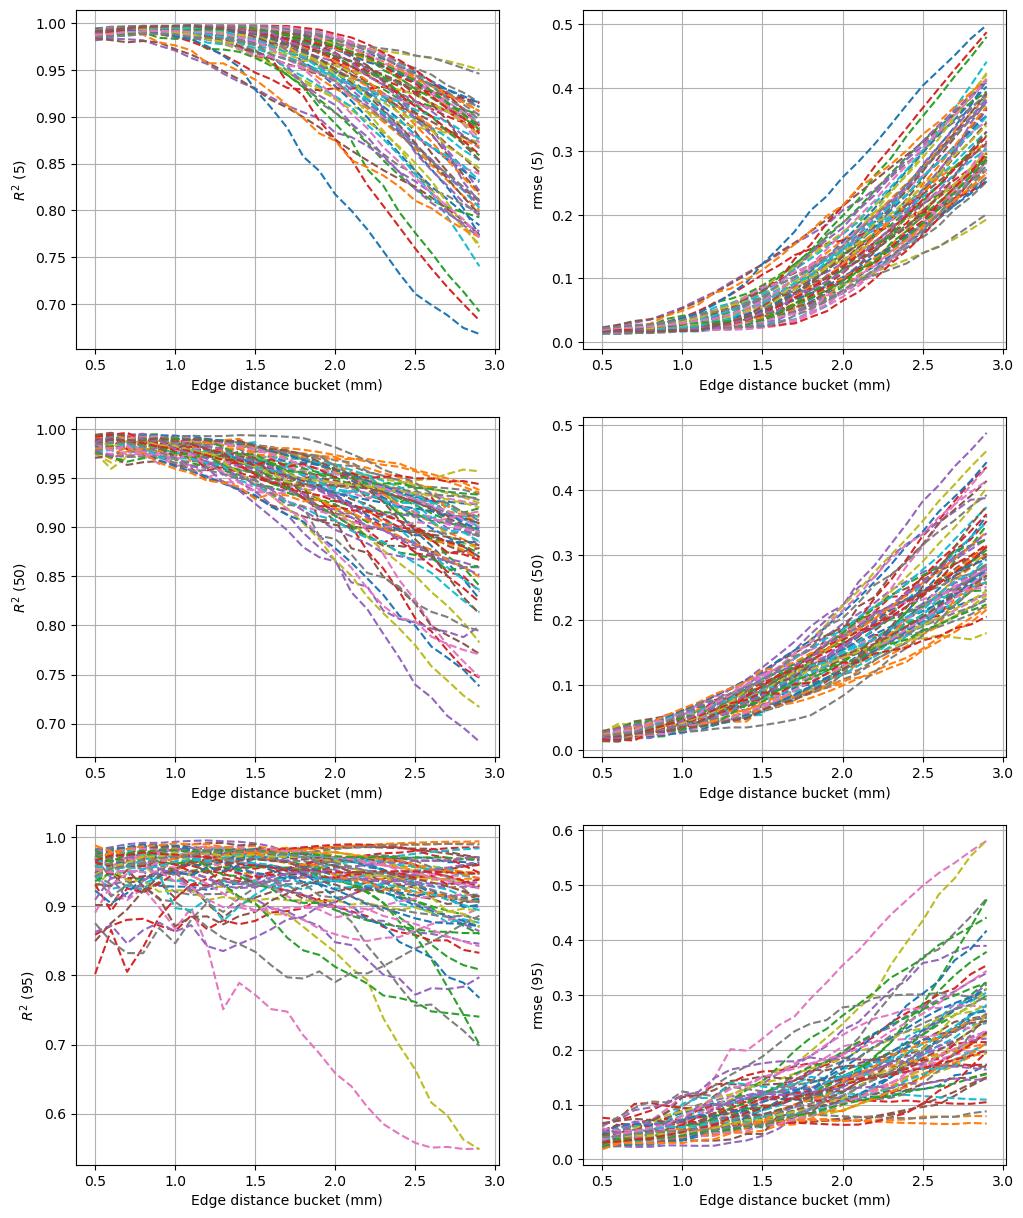

In [272]:
fig, ax = plt.subplots(3, 2, figsize=(12, 15))
ax = ax.flatten()

subs = df.subject.unique()
bones = df.bone.unique()
x = df.bucket.unique()
for sub in subs:
    for bn in bones:
        sub_df = df[(df['subject']==sub) & (df['bone']==bn)]

        ax[0].plot(x, sub_df['r2_5'], linestyle='--')
        ax[1].plot(x, sub_df['rmse_5'], linestyle='--')
        ax[2].plot(x, sub_df['r2_50'], linestyle='--')
        ax[3].plot(x, sub_df['rmse_50'], linestyle='--')
        ax[4].plot(x, sub_df['r2_95'], linestyle='--')
        ax[5].plot(x, sub_df['rmse_95'], linestyle='--')


ax[0].set_ylabel('$R^2$ (5)')
ax[1].set_ylabel('rmse (5)')
ax[2].set_ylabel('$R^2$ (50)')
ax[3].set_ylabel('rmse (50)')
ax[4].set_ylabel('$R^2$ (95)')
ax[5].set_ylabel('rmse (95)')

#ax.legend()
for ax_i in ax:
    ax_i.set_xlabel('Edge distance bucket (mm)')
    ax_i.grid()
plt.show()

### Thoughts
 - Think just tapering from set distance all the way around makes the most sense - none of this under taper curve stuff
    - Also same for cutoff for everyone (obv)
 - Want to identify at what distance from the boundary the unnatural, almost systematic like, increase (flaring) in cartilage height begins.
 - this change is most blatant for areas that have small gap between bones, close the boundary
    - because growth rate is highest
 - So used this to indicate where taper should start then used plots below to verify that theory
    - see markdown just below and thoughts on how to demonstrate this with plots of points on geodesic paths from the centre.
 - Tempting to be conservative with taper height and choose very small but this allows known atifact of method to have impact
    - think it's better to pick sensible value like 1.5 and have steeper taper region so that height is essentially kept constant before then tapering down to bone surface.

#### 1.5 -> 1.75 mm seems reasonable  -  go with 1.5mm to be slightly conservative?

In [ ]:
could also measure dot product between midpoint vectors and normal vectors
 - around the edge the dot product will be lower? - think this just depends on the local geometry?

## Understanding where the taper region should start
 - Below shows the method development for the code above
 - First plot shows:
    - as you move outwards from the centre of the cartilage, there is a sudden increase in cartilage height
        - some of which might be natural as that part of cartilage isn't as worn
        - but some of it is unnatural artifact of height field method

- When writing up, show these plots before and after tapering and show rendering of actual cartilage mesh, before and after tapering.
    - show selection to get point accross
    - show fit quality plots and point out that at around 1.5 mm is when quality drop occurs, then say looking at selection of the 2d plots below shows where this is and that it corresponds to the almost uniform linear rise in thickness around entire cartilage region that results in unnnatiural cliff edge
         - fact it is uniform global behaviour indicates it is unnnatural
         - the rest of the field shows less global behaviour more variance
            - should colour a selection of geodesic paths (from centre to boundary) on the plots based on anatomical location around the field. To show that in different locations behaviour is different in the inner region, but then they all display same unnatural growth beginning at the same time 1.5 mm from the edge.

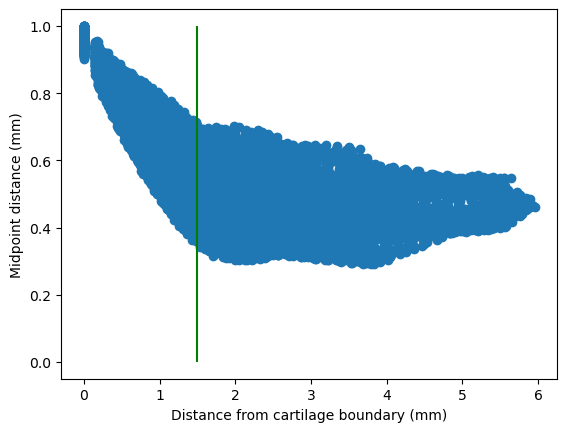

In [ ]:
# sub i = -1

fig, ax = plt.subplots()

max_x = 2
x = np.linspace(0, max_x, 100)
y = taper_f(x=x, max_x=max_x, max_y=1, p=1)
#ax.plot(x, y, c='g')
ax.scatter(geo_dists, min_df['dist']/2)

ax.vlines([1.5], 0, 1, color='g')

ax.set_xlabel('Distance from cartilage boundary (mm)')
ax.set_ylabel('Midpoint distance (mm)')

plt.show()

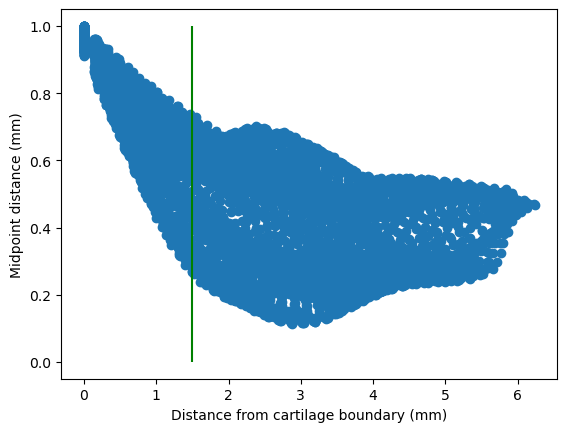

In [45]:
# sub i = 1

fig, ax = plt.subplots()

ax.scatter(geo_dists, min_df['dist']/2)
ax.vlines([1.5], 0, 1, color='g')

ax.set_xlabel('Distance from cartilage boundary (mm)')
ax.set_ylabel('Midpoint distance (mm)')

plt.show()

In [ ]:
from scipy.stats import linregress
def compute_r2(group_df, i):
    x = group_df[['midpoint_dist']].iloc[:i]
    y = group_df[['edge_dist_bucket']].iloc[:i]
    res95 = linregress(x, y)
    return res95.rvalue**2

df = pd.DataFrame({'edge_dist': geo_dists, 'midpoint_dist': min_df['dist']/2})
df['edge_dist_bucket'] = np.floor(df['edge_dist'] / 0.1) * 0.1 # 0->0.99999, 0.1->1.99999...

group = df.groupby('edge_dist_bucket')['midpoint_dist']
print('Minimum bucket count in first 4 mm:', group.count().head(40).min()) # first 4mm count

# 95th and 5th percentile for each bucket
pct95 = group.quantile(0.95).reset_index()
pct5 = group.quantile(0.05).reset_index()

start, end = 6, 40 # from first 2 buckets -> 39th bucket (3.99999... mm)
data = []

r2s95 = []
r2s5 = []
for i in range(start, end):
    r2s95.append(compute_r2(pct95, i))
    r2s5.append(compute_r2(pct5, i))
    

Minimum bucket count in first 4 mm: 78


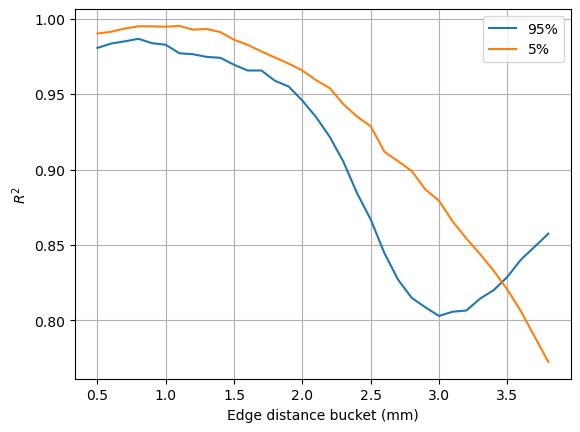

In [185]:
fig, ax = plt.subplots()

x = pct95[['edge_dist_bucket']].iloc[start-1:i]

ax.plot(x, r2s95, label='95%')
ax.plot(x, r2s5, label='5%')

ax.set_ylabel('$R^2$')
ax.set_xlabel('Edge distance bucket (mm)')

ax.legend()
ax.grid()
plt.show()

# TAPER SHAPE

#### Set p to higher value so that height is kept constant before quick taper down
 - that way no unnatural rise but also no sudden drop - more natural (hopefully...)
    - essentially, admitting that we don't know what happens to the cartilage in this region but can be confident that it doesn't have the unnatural rise to a 1mm cliff - so choosing to remove that and replace with very gradual drop until around taper_width/2 , followed by much steeper drop.

## Choose p_h based on what the angle tends towards at 0  -  p_h = 8.5
- point of contact with bone not in direct contact so prioritise creating geometry with favourable conditions for creating high quality tets 
- Rather than allow flare to cliff or sudden reduction prefer to keep constant and then taper in at angle that gives optimal range of dihdral angles for range of max_y's in the data ! 
     - max_y is the height at 1.5 mm - it is local so has range shown below
- dihedral angle of regular tet = 70.53
- look at range of y values at 1.5mm from boundary
     - base it on 0.5mm max_y

In [8]:
df = pd.read_csv('taperShapeMetrics.csv')
df.describe()

,h_min,h_max,h_mean,h_median,h_95,h_5
count,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000
mean,0.275535,0.760442,0.509731,0.504241,0.708003,0.319716
std,0.076533,0.076200,0.051309,0.055449,0.073223,0.069202
min,0.156317,0.596086,0.396694,0.403947,0.555634,0.212657
25%,0.221304,0.716766,0.482529,0.471211,0.668609,0.268744
50%,0.252913,0.754209,0.509165,0.498909,0.708009,0.303689
75%,0.333480,0.816641,0.542749,0.544373,0.751807,0.370632
max,0.494944,0.919196,0.638973,0.642250,0.878795,0.507528


In [17]:
fel = 0.2

max_y = 0.5
p = 8.5
x = np.linspace(0, taper_width, 100)

y = taper_f(x, taper_width, 1, p)
def taper_angle_at_0(max_x, max_y, p=2, degrees=True):
    slope = p * max_y / max_x
    angle = np.arctan(slope)
    return np.degrees(angle) if degrees else angle

taper_angle_at_0(taper_width, max_y, p)

np.float64(70.55996517182382)

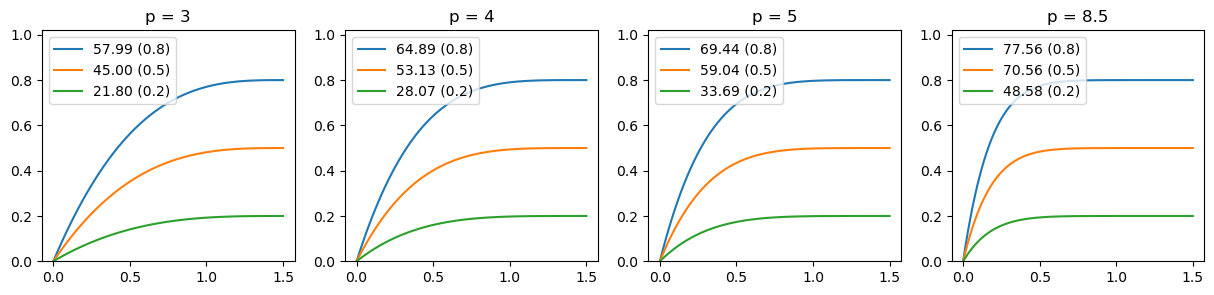

In [33]:

fig, ax = plt.subplots(1, 4, figsize=(15, 3))

ps = [3, 4, 5, 8.5]
for i, p in enumerate(ps):
    for my in [0.8, 0.5, 0.2]:
        x = np.linspace(0, taper_width, 100)
        y = taper_f(x, max(x), my, p)

        ang = taper_angle_at_0(taper_width, my, p)
        ax[i].plot(x, y, label=f'{ang:.2f} ({my})')

        ax[i].set_title(f'p = {p}')
        ax[i].set_ylim([0, 1.02])

for ax_i in ax:
    ax_i.legend()
plt.show()

### Below has been updated to reflect changes decided above
 - taper width set to 1.5 everywhere
    - no more under taper curve - just distance based
    - which means no more max height
 - p_h = 8.5
    - good dihedral angles
    - can see if there is a better function if can be bothered
   

# Smoothing
 - Smooth because of empty channels that form due to geometry of opposing bone
 - and this surface is important for contact so don't want sharp edges that cause pressure spikes - on famously smooth cartilage
 - lapalacian smoothing behaves nicer than taubin for the open surface
 - most of the movement happends in the taper region where it helps smooth out aftifacts of simple face projection and blending vector directions

In [ ]:
import numpy as np
import pandas as pd
import pyvista as pv
import gdist
from scipy.spatial.distance import cdist
from pathlib import Path
import subprocess
import pymeshfix
import matplotlib.pyplot as plt
from tqdm import tqdm

from phd_helpers.CartilageGeneration import (
    mesh_checks, bone_cartilage_checks, get_outward_normal_mask, flip_faces, taper_f, get_nearest_boundary, 
    interp_vecs, get_triangle_adjacency, flood_fill_cells, remove_normals, get_min_df_fast, check_points_still_there,
    fill_holes_pmf
)
from phd_helpers.paths import (
    find_corresponding_cells, identical_points_count, get_subject_stl_path, get_boundary
)


def compute_dists(cartilage_cap, mesh_clean):
    a = cartilage_cap.points[cartilage_cap['inner_points'].astype(bool)]
    b = mesh_clean
    _, ps = b.find_closest_cell(a, return_closest_point=True)
    return np.linalg.norm(ps - a, axis=1)

def compute_rmsd(dists):
    return float(np.sqrt(np.mean(dists**2)))

def combine_rmsd(rmsd_ab, rmsd_ba):
    return float(np.sqrt(0.5 * (rmsd_ab**2 + rmsd_ba**2)))

In [5]:
# INPUTS #

bone, ar_bone = 'tpm', 'mc1'
mesh_id = '-0'

# meshes have 2.5mm of 0.2mm fine mesh for 50 taubin input
output_root = Path('outputs/cartilage_ok/meshes')

# main params
remesh_cartilage = True
cartilage_remesh_name = f'CartilageCap.obj' # cartilage cap mesh file name
# path to c++ fixed boundary input
cgal_input_path = Path(f'../../../../MeshPipeline/cpp/2Dmesh/inputs/fb_input/{cartilage_remesh_name}')

taper_width = 1.5 # width of cartilage taper region (limit - only tapers if above taper curve)
#max_height = 1 # max height of cartilage in taper region
p_h = 8.5 # shape of taper height (1 = linear , higher = steeper taper)
p_v = 1 # shape of vector ratio (1 = linear)
cartilage_smooth_iters = 100 # need to look at this, currently uses laplacian 
edge_length = 0.2 # target edge length of cartilage remesh
n_iters = 10 # n isotropic remeshing iterations for cartilage remesh

In [6]:
iters = [25, 50, 100, 200, 400, 800, 1600]

smooth_data = []
for sub in tqdm(subs_ok):
    subject, sideL = sub[:-1], sub[-1]
    for bone, ar_bone in [['tpm', 'mc1'], ['mc1', 'tpm']][:1]:   


        output_dir = output_root / f"{subject}{sideL}/{bone}-{ar_bone}"
        output_path = output_dir / '2Dmesh'
        compute_quality = False

        bone_mesh = pv.read(output_path / f'bone_remesh{mesh_id}.obj')
        ar_path = output_dir.parent / f"{ar_bone}-{bone}/2Dmesh/bone_remesh{mesh_id}.obj"
        arbone_mesh = pv.read(ar_path)

        # compute min df
        stl_path = get_subject_stl_path(subject, sideL)
        max_gap_cartilage = 2
        poses = ['adduction','abduction','flexion','extension','pinch','grasp','jar','neutral']
        min_df = get_min_df_fast(stl_path, bone, ar_bone, bone_mesh, arbone_mesh, poses, max_gap_cartilage)





        # main
        ################# MESH STUFF #################
        bone_mesh['Normals'] = bone_mesh.compute_normals(point_normals=True, cell_normals=False)['Normals']
        bone_mesh['bone_id'] = np.arange(bone_mesh.n_points)
        bone_mesh['bone_cell_id'] = np.arange(bone_mesh.n_cells)
        ################# MESH STUFF #################


        ################# COMPUTE TAPER REGION #################
        # extract mesh of cartilage points on bone mesh (makes gdist computation faster) - (bone-cartilage interface mesh)
        inter_mesh = bone_mesh.extract_points(min_df['bone_id'], adjacent_cells=False).extract_surface(algorithm=None)
        inter_mesh['inter_cell_ids'] = np.arange(inter_mesh.n_cells)
        # remove any missing points due to extract geometry (so remove any points not part of a complete triangle)
        missing_mask = ~np.isin(min_df['bone_id'], inter_mesh['bone_id'])
        min_df.drop(min_df['bone_id'][missing_mask].index.values, inplace=True)

        # useful values from min_df (min_df does not change after this point - final change was at min_df.drop(missing))
        midpoint_dist = min_df['dist'] / 2 # distance of midpoint between two bones for each pair of closest points
        midpoints = np.array(min_df['midpoint'].tolist()) # midpoint coordinates
        #ar_points = np.array(min_df['ar_point'].tolist()) # closest points on ar bone to each bone point


        # get boundary of cartilage on inter mesh
        inter_boundary = get_boundary(inter_mesh)
        boundary_mask_inter = np.isin(inter_mesh['bone_id'], inter_boundary['bone_id']) 
        boundary_ids = np.arange(inter_mesh.n_points)[boundary_mask_inter] # on inter_mesh

        # minimum geo dist of every node from closest source_idx
        geo_dists = gdist.compute_gdist(
            inter_mesh.points.astype(np.float64),
            inter_mesh.faces.reshape(-1, 4)[:, 1:].astype(np.int32),
            source_indices=boundary_ids.astype(np.int32), 
        ) 

        # get mask of nodes within taper width and below taper function
        #taper_heights = taper_f(geo_dists, taper_width, max_height, p=p_h)
        #taper_mask = (taper_heights <= min_df['dist'] / 2) & (geo_dists<=taper_width)
        taper_mask = geo_dists<=taper_width




        # get taper points mesh (makes computation much faster) - mesh of only taper region
        taper_mask_inter = np.isin(inter_mesh['bone_id'], min_df['bone_id'][taper_mask])
        taper_mesh = inter_mesh.extract_points(taper_mask_inter, adjacent_cells=False).extract_surface(algorithm=None)
            # assign non-taper cells that lie on "pinched" islands to taper region
        not_taper_mesh = inter_mesh.extract_cells(taper_mesh['inter_cell_ids'], invert=True).extract_surface(algorithm=None)
        edge_map, adjacency = get_triangle_adjacency(not_taper_mesh)
        start_face = not_taper_mesh.find_closest_cell(np.mean(not_taper_mesh.points, axis=0)) # not best way of doing this!
        inner_cells = flood_fill_cells(not_taper_mesh, start_face, get_boundary(not_taper_mesh).lines.reshape(-1, 3)[:, 1:], adjacency)
            # final taper mesh #
        taper_mesh = inter_mesh.extract_cells(not_taper_mesh['inter_cell_ids'][inner_cells], invert=True).extract_surface(algorithm=None)
            # remove any missing points from taper_mask after extracting geometry and islands - not ideal but quicker than using inter mesh
        taper_mask = np.isin(min_df['bone_id'], taper_mesh['bone_id'])
        #taper_geo_dists = geo_dists[taper_mask]

        # geo_dist between all points within max_distance
        geo_dists_matrix = gdist.local_gdist_matrix(
            taper_mesh.points.astype(np.float64),
            taper_mesh.faces.reshape(-1, 4)[:, 1:].astype(np.int32),
            max_distance=taper_width+1e-3
        ) 

        # get taper mesh boundaries
        taper_boundary = get_boundary(taper_mesh)
        boundary_outer_mask_tb = np.isin(taper_boundary['bone_id'], inter_boundary['bone_id']) # on taper_boundary

        # get taper boundary innner and outer nodes on taper mesh
        taper_outer_mask = np.isin(taper_mesh['bone_id'], taper_boundary['bone_id'][boundary_outer_mask_tb]) # on taper_mesh
        taper_inner_mask = np.isin(taper_mesh['bone_id'], taper_boundary['bone_id'][~boundary_outer_mask_tb]) # on taper_mesh
        taper_outer_ids = np.arange(taper_mesh.n_points)[taper_outer_mask] # on taper_mesh
        taper_inner_ids = np.arange(taper_mesh.n_points)[taper_inner_mask] # on taper_mesh

        # ids and distances of boundary nodes that are closest to each taper node
        _, near_taper_outer_D = get_nearest_boundary(taper_outer_ids, geo_dists_matrix) # ids on taper_mesh
        near_taper_inner_ids, near_taper_inner_D = get_nearest_boundary(taper_inner_ids, geo_dists_matrix) # ids on taper_mesh
        # Distance fraction of each taper_mesh point from closest outer_node to closest_inner node
        taper_Df = (near_taper_outer_D) / (near_taper_outer_D + near_taper_inner_D)

        # get nearest inner node midpoint heights
        taper_inner_mask_c = np.isin(min_df['bone_id'], taper_mesh['bone_id'][taper_inner_ids]) # on c_mesh
        inner_node_midpoint_heights = midpoint_dist.values[taper_inner_mask_c]
        near_inner_node_midpoint_heights = inner_node_midpoint_heights[np.searchsorted(taper_inner_ids, near_taper_inner_ids)]

        # set taper node heights
        taper_heights = taper_f(taper_Df, 1, near_inner_node_midpoint_heights, p=p_h) # non-linear

        # set vector directions
        midpoint_vecs = midpoints - bone_mesh.points[min_df['bone_id']] # vector from bone point to midpoint
        taper_vecs_mid = midpoint_vecs[taper_mask] # midpoint_vecs
        taper_vecs_norm = bone_mesh['Normals'][min_df['bone_id']][taper_mask] # normal vecs
        vec_dirs = taper_f(taper_Df, 1, 1, p=p_v)
        taper_vecs = interp_vecs(taper_vecs_norm, taper_vecs_mid, vec_dirs)

        # get taper coords
        taper_points = bone_mesh.points[min_df['bone_id']][taper_mask]
        taper_points = taper_points + taper_heights.reshape(-1, 1)*taper_vecs

        # get taper points
        points_tapered = midpoints.copy()
        points_tapered[taper_mask] = taper_points

        #closest_points, distances, cell_ids = get_trimesh(bone_mesh).nearest.on_surface(points_tapered)
        ################# COMPUTE TAPER REGION #################

        ################# MESH TAPER REGION #################
        # map faces from bone mesh to extruded taper region points
        # mesh curves down in taper region and delaunay doesn't like that
        tapered_mesh = pv.PolyData(taper_points, taper_mesh.faces)
        ################# MESH TAPER REGION #################




        ################# MESH INNER REGION #################
        tapered_edge = get_boundary(tapered_mesh)

        inner_edge = tapered_edge.extract_points(~boundary_outer_mask_tb).extract_surface(algorithm=None)
        #inner_points = pv.PolyData(midpoints[~taper_mask])
        inner_mesh = pv.PolyData(np.vstack( (inner_edge.points, midpoints[~taper_mask]) ), lines=inner_edge.lines)

        # alpha for coarse meshes wants to be slightly lower and vice versa - I think
        inner_mesh = inner_mesh.delaunay_2d(edge_source=inner_edge, alpha=0.9).triangulate()
        inner_mesh = inner_mesh.fill_holes(inner_mesh.area/20)
        #inner_mesh.lines = inner_edge.lines # reset edge lines to remove delaunay leftover lines
        inner_mesh.lines = np.empty(0, dtype='int64') # remove all lines for now cos they show up in mesh.faces

        # remove cells that lie outside of the inner region boundary
        edge_map, adjacency = get_triangle_adjacency(inner_mesh)
        #start_face = inner_mesh.find_closest_cell(np.mean(inner_mesh.points, axis=0))
        start_face = inner_mesh.find_closest_cell(inner_mesh.center) # new 28/03/26
        inner_cells = flood_fill_cells(inner_mesh, start_face, inner_edge.lines.reshape(-1, 3)[:, 1:], adjacency)
        inner_mesh_clean = pv.PolyData(inner_mesh.points, inner_mesh.faces.reshape(-1, 4)[inner_cells])
        # should maybe be calling remove unused points here, lines bring their own points that are left behind?
        ################# MESH INNER REGION #################




        ################# COMBINE INNER MESH AND TAPER MESH #################
        #edge_check1 = np.isin(inner_edge.points, tapered_mesh.points).all()
        edge_check1 = identical_points_count(inner_edge.points, tapered_mesh.points) == inner_edge.n_points #*** new
        #edge_check2 = np.isin(inner_edge.points, inner_mesh_clean.points).all()
        edge_check2 = identical_points_count(inner_edge.points, inner_mesh_clean.points) == inner_edge.n_points #*** new

        inner_mesh_clean['inner_cells'] = np.full(inner_mesh_clean.n_cells, 1)
        tapered_mesh['inner_cells'] = np.full(tapered_mesh.n_cells, 0)
        mesh = inner_mesh_clean + tapered_mesh # full cartilage cap mesh
            # check if there are any holes at boundary between inner mesh and tapered mesh and try to fill them
        if get_boundary(mesh).connectivity()['RegionId'].any():
            mesh = fill_holes_pmf(mesh, nbe=20)
            mesh['inner_cells'] = np.ones(mesh.n_cells, dtype=int)
            mesh['inner_cells'][find_corresponding_cells(mesh, tapered_mesh, raise_error=True)] = 0
        else:
            if not mesh.n_points == midpoints.shape[0]: # had to move to else cos pymeshfix messes with stuff sometimes
                raise AssertionError('Not all midpoints in mesh (& no dupes)')

        if not edge_check1:
            raise AssertionError('Not all boundary points in tapered mesh')
        if not edge_check2:
            raise AssertionError('Not all boundary points in inner mesh')

        # check for flat faces
        #closest_points, implicit_distances, cell_ids = get_trimesh(bone_mesh).nearest.on_surface(mesh.points)
        _, ps = bone_mesh.find_closest_cell(mesh.points, return_closest_point=True)
        implicit_distances = np.linalg.norm(mesh.points - ps, axis=1) #*** changed from line above

        mesh_faces = mesh.faces.reshape(-1, 4)[:, 1:]
        flat_face_mask = (implicit_distances[mesh_faces] <= 1e-12).all(axis=1) #*** changed from ==0 to <=1e-12
        #flat_face_ids = np.where(flat_face_mask)[0]

        # remove flat faces and leftover points - occur when all 3 vertices lie on the boundary
        mesh_clean = pv.PolyData(mesh.points, mesh.faces.reshape(-1, 4)[~flat_face_mask]).compute_normals(auto_orient_normals=True)
        mesh_clean.remove_unused_points(inplace=True)
        mesh_clean['mesh_clean_id'] = np.arange(mesh_clean.n_points)
        # get array of inner points/cells on mesh_clean 
        mesh_clean['inner_cells'] = mesh['inner_cells'][find_corresponding_cells(mesh, mesh_clean)]
        mesh_clean['inner_points'] = np.full(mesh_clean.n_points, 1)
        mesh_clean['inner_points'][np.unique(mesh_clean.faces.reshape(-1, 4)[:, 1:][np.where(mesh_clean['inner_cells']==0)[0]])] = 0
        #mesh_clean['inner_points'] = np.zeros(mesh_clean.n_points, dtype=int)
        #for p in inner_mesh_clean.points:
        #    mesh_clean['inner_points'][mesh_clean.find_closest_point(p)] = 1

        # get edge points on mesh and bone_mesh
        mesh_clean_edge = get_boundary(mesh_clean)
        mesh_clean_edge_mask = np.isin(mesh_clean['mesh_clean_id'], mesh_clean_edge['mesh_clean_id']) # on mesh_clean
        mesh_edge_ids = mesh_clean['mesh_clean_id'][mesh_clean_edge_mask] # on mesh_clean
        mesh_edge_points = mesh_clean.points[mesh_clean_edge_mask] # on mesh_clean

        #print('Checking mesh boundary has not changed')
        #bone_mesh_edge_ids = check_points_still_there(bone_mesh, mesh_edge_points)
        _, bone_mesh_edge_ids, _ = identical_points_count(bone_mesh.points, mesh_edge_points, return_indices=True) #*** new
        bone_mesh_edge_ids = np.sort(bone_mesh_edge_ids)
        if len(bone_mesh_edge_ids) != len(mesh_edge_points):
            raise AssertionError("Mesh boundary has changed")


        if (mesh.n_cells - mesh_clean.n_cells) != flat_face_mask.sum():
            raise AssertionError("Not all flat faces removed")
        ################# COMBINE INNER MESH AND TAPER MESH #################
        #print('Created cartilage cap')




        for n_iter in iters:
            #print('Smoothing cartilage cap')
            ################# SMOOTH CARTILAGE MESH CAP #################
            cartilage_cap = mesh_clean.smooth(
            n_iter=n_iter,
            feature_angle=180, # prevent anything from being feature cos I don't understant feature_smoothing arg...
            boundary_smoothing = False, # keeps boundary fixed-ish
            feature_smoothing = False # prevents feature edges from being identified - so they get smoothed?... (idk stupid)
            )
            cartilage_cap_edge = get_boundary(cartilage_cap)

            if cartilage_cap_edge.n_points != mesh_clean_edge.n_points:
                raise AssertionError(f'{cartilage_cap_edge.n_points - mesh_clean_edge.n_points} Boundary points lost during smoothing')
            #_ = check_points_still_there(mesh_clean_edge, cartilage_cap_edge.points)

            # put edge points back so they are numerically identical
            cartilage_cap.points[mesh_edge_ids] = bone_mesh.points[bone_mesh_edge_ids]

            d_ab = compute_dists(cartilage_cap, mesh_clean)
            d_ba = compute_dists(mesh_clean, cartilage_cap)
            d = np.hstack((d_ab, d_ba))
            rmsd_ab = compute_rmsd(d_ab)
            rmsd_ba = compute_rmsd(d_ba)
            smooth_data.append({
                'subject': sub,
                'bone':bone, 
                'iters': n_iter,
                'A_before': mesh_clean.area,
                'A_after': cartilage_cap.area,
                'rmsd_ab': rmsd_ab,
                'rmsd_ba': rmsd_ba,
                'rmsd_2way': combine_rmsd(rmsd_ab, rmsd_ba),
                'rmsd': compute_rmsd(d),
                'd_mean': np.mean(d),
                'd_min': np.min(d),
                'd_max': np.max(d),
                'd_median': np.median(d),
                'd_std': np.std(d),
                'd_95': np.percentile(d, 95),
                'd_5': np.percentile(d, 5),
            })

#pd.DataFrame(smooth_data).to_csv('taperSmoothingMetrics.csv', index=False)


 32%|███▏      | 11/34 [00:46<01:36,  4.20s/it]

INFO- Loaded 5916 vertices and 11512 faces.

100% done 


100%|██████████| 34/34 [02:24<00:00,  4.26s/it]


### Measure difference between mesh_clean (before) and cartilage_cap (after smoothing)

In [8]:
df = pd.read_csv('taperSmoothingMetrics.csv')
df

,subject,bone,iters,A_before,A_after,rmsd_ab,rmsd_ba,rmsd_2way,rmsd,d_mean,d_min,d_max,d_median,d_std,d_95,d_5
0,14548R,tpm,25,169.626552,168.449007,0.000687,0.001028,0.000874,0.000874,0.000577,1.873734e-07,0.010443,0.000391,0.000657,0.001706,0.000036
1,14548R,tpm,50,169.626552,167.519743,0.001313,0.001841,0.001599,0.001599,0.001083,7.266390e-08,0.017701,0.000748,0.001177,0.003217,0.000071
2,14548R,tpm,100,169.626552,166.095021,0.002466,0.003170,0.002840,0.002840,0.001986,4.478997e-07,0.027871,0.001432,0.002030,0.005770,0.000136
3,14548R,tpm,200,169.626552,164.110644,0.004606,0.005382,0.005009,0.005009,0.003623,1.468064e-06,0.041629,0.002653,0.003459,0.010341,0.000259
4,14548R,tpm,400,169.626552,161.541003,0.008635,0.009322,0.008985,0.008985,0.006678,1.555727e-06,0.061502,0.005104,0.006012,0.018660,0.000442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,50053R,tpm,100,281.955064,276.494491,0.001998,0.002558,0.002295,0.002295,0.001506,2.438364e-07,0.026782,0.001019,0.001732,0.004529,0.000094
234,50053R,tpm,200,281.955064,273.222722,0.003724,0.004356,0.004053,0.004053,0.002764,2.384172e-07,0.038942,0.001915,0.002964,0.008196,0.000187
235,50053R,tpm,400,281.955064,268.859500,0.006969,0.007582,0.007282,0.007282,0.005153,3.257207e-06,0.054260,0.003686,0.005145,0.014763,0.000348
236,50053R,tpm,800,281.955064,263.441024,0.013037,0.013592,0.013318,0.013318,0.009675,1.736586e-06,0.076264,0.007348,0.009152,0.026565,0.000592


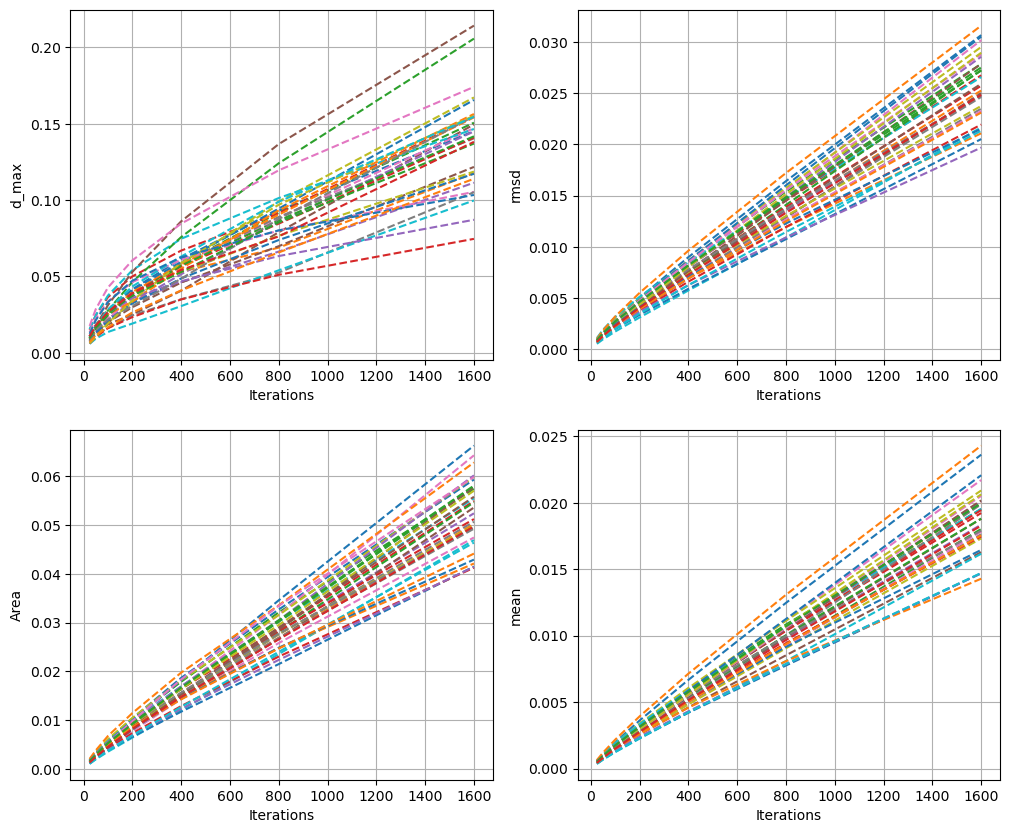

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax = ax.flatten()

subs = df.subject.unique()
bones = df.bone.unique()
x = df.iters.unique()
for sub in subs:
    for bn in bones:
        sub_df = df[(df['subject']==sub) & (df['bone']==bn)]

        ax[0].plot(x, sub_df['d_max'], linestyle='--')
        ax[1].plot(x, sub_df['rmsd'], linestyle='--')
        ax[2].plot(x, sub_df['d_95'], linestyle='--')
        ax[3].plot(x, sub_df['d_mean'], linestyle='--')



ax[0].set_ylabel('d_max')
ax[1].set_ylabel('rmsd')
ax[2].set_ylabel('Area')
ax[3].set_ylabel('mean')


#ax.legend()
for ax_i in ax:
    ax_i.set_xlabel('Iterations')
    ax_i.grid()
plt.show()

# 100 iterations is fine

In [29]:
pl = pv.Plotter()
pl.add_mesh(cartilage_cap, scalars='inner_cells', cmap='Accent')
pl.add_points(cartilage_cap.points[cartilage_cap['inner_points'].astype(bool)][np.argmax(d)])
pl.show()

Widget(value='<iframe src="http://localhost:62454/index.html?ui=P_0x33dc581a0_10&reconnect=auto" class="pyvist…

# Full code (with all new params and bug fixes as of start of April 2026)

In [1]:
import numpy as np
import pandas as pd
import pyvista as pv
import gdist
from scipy.spatial.distance import cdist
from pathlib import Path
import subprocess
import pymeshfix
import matplotlib.pyplot as plt
from tqdm import tqdm

from phd_helpers.CartilageGeneration import (
    mesh_checks, bone_cartilage_checks, get_outward_normal_mask, flip_faces, taper_f, get_nearest_boundary, 
    interp_vecs, get_triangle_adjacency, flood_fill_cells, remove_normals, get_min_df_fast, check_points_still_there,
    fill_holes_pmf
)
from phd_helpers.paths import (
    find_corresponding_cells, identical_points_count, get_subject_stl_path, get_boundary
)


In [11]:
# INPUTS #

bone, ar_bone = 'tpm', 'mc1'
mesh_id = '-0'

# meshes have 2.5mm of 0.2mm fine mesh for 50 taubin input
output_root = Path('outputs/cartilage_ok/meshes')
subs_sides = [p.name for p in output_root.iterdir() if p.is_dir()]

# select subject - subs_ok (above) only includes subjects that can generate cartilage 
i = 1
#subject, sideL = subs_ok[i][:-1], subs_ok[i][-1]
subject, sideL = '14548', 'R'
#subject, sideL = '14613', 'R'
#subject, sideL = '15006', 'R'

#subject, sideL = '15441', 'R' # cartilage normals point inwards

# main params
remesh_cartilage = True
cartilage_remesh_name = f'CartilageCap.obj' # cartilage cap mesh file name
# path to c++ fixed boundary input
cgal_input_path = Path(f'../../../../MeshPipeline/cpp/2Dmesh/inputs/fb_input/{cartilage_remesh_name}')

taper_width = 1.5 # width of cartilage taper region (limit - only tapers if above taper curve)
#max_height = 1 # max height of cartilage in taper region
p_h = 8.5 # shape of taper height (1 = linear , higher = steeper taper)
p_v = 1 # shape of vector ratio (1 = linear)
cartilage_smooth_iters = 100 # need to look at this, currently uses laplacian 
edge_length = 0.2 # target edge length of cartilage remesh
n_iters = 5 # n isotropic remeshing iterations for cartilage remesh
clamp_height = 0.06 # minimum cartilage height

In [12]:


output_dir = output_root / f"{subject}{sideL}/{bone}-{ar_bone}"
output_path = output_dir / '2Dmesh'
compute_quality = False

bone_mesh = pv.read(output_path / f'bone_remesh{mesh_id}.obj')
ar_path = output_dir.parent / f"{ar_bone}-{bone}/2Dmesh/bone_remesh{mesh_id}.obj"
arbone_mesh = pv.read(ar_path)

# compute min df
stl_path = get_subject_stl_path(subject, sideL)
max_gap_cartilage = 2
poses = ['adduction','abduction','flexion','extension','pinch','grasp','jar','neutral']
min_df = get_min_df_fast(stl_path, bone, ar_bone, bone_mesh, arbone_mesh, poses, max_gap_cartilage)



# main
################# MESH STUFF #################
bone_mesh['Normals'] = bone_mesh.compute_normals(point_normals=True, cell_normals=False)['Normals']
bone_mesh['bone_id'] = np.arange(bone_mesh.n_points)
bone_mesh['bone_cell_id'] = np.arange(bone_mesh.n_cells)
################# MESH STUFF #################


################# COMPUTE TAPER REGION #################
# extract mesh of cartilage points on bone mesh (makes gdist computation faster) - (bone-cartilage interface mesh)
inter_mesh1 = bone_mesh.extract_points(min_df['bone_id'], adjacent_cells=False).extract_surface(algorithm=None)

# JUST REMOVE ANY ISLANDS
conn = inter_mesh1.connectivity(label_regions=True)
region_ids = conn.cell_data["RegionId"]
island_ids, counts = np.unique(region_ids, return_counts=True)
largest_region_id = island_ids[np.argmax(counts)]
inter_mesh = inter_mesh1.extract_cells(np.where(region_ids == largest_region_id)[0]).extract_surface(algorithm=None)
inter_mesh['inter_cell_ids'] = np.arange(inter_mesh.n_cells)

# remove any missing points due to extract geometry (incomplete triangles) and islands
missing_mask = ~np.isin(min_df['bone_id'], inter_mesh['bone_id'])
min_df.drop(min_df['bone_id'][missing_mask].index.values, inplace=True)

# useful values from min_df (min_df does not change after this point - final change was at min_df.drop(missing))
midpoint_dist = min_df['dist'] / 2 # distance of midpoint between two bones for each pair of closest points
midpoints = np.array(min_df['midpoint'].tolist()) # midpoint coordinates
#ar_points = np.array(min_df['ar_point'].tolist()) # closest points on ar bone to each bone point


# get boundary of cartilage on inter mesh
inter_boundary = get_boundary(inter_mesh)
boundary_mask_inter = np.isin(inter_mesh['bone_id'], inter_boundary['bone_id']) 
boundary_ids = np.arange(inter_mesh.n_points)[boundary_mask_inter] # on inter_mesh

# minimum geo dist of every node from closest source_idx
geo_dists = gdist.compute_gdist(
    inter_mesh.points.astype(np.float64),
    inter_mesh.faces.reshape(-1, 4)[:, 1:].astype(np.int32),
    source_indices=boundary_ids.astype(np.int32), 
) 

# get mask of nodes within taper width and below taper function
#taper_heights = taper_f(geo_dists, taper_width, max_height, p=p_h)
#taper_mask = (taper_heights <= min_df['dist'] / 2) & (geo_dists<=taper_width)
taper_mask = geo_dists<=taper_width



In [33]:
pl = pv.Plotter()
pl.add_mesh(inter_mesh, color='gray')
pl.add_points(inter_mesh.points[taper_mask])
pl.show()

Widget(value='<iframe src="http://localhost:50920/index.html?ui=P_0x3200b7920_8&reconnect=auto" class="pyvista…

In [13]:

# get taper points mesh (makes computation much faster) - mesh of only taper region
taper_mask_inter = np.isin(inter_mesh['bone_id'], min_df['bone_id'][taper_mask])
taper_mesh = inter_mesh.extract_points(taper_mask_inter, adjacent_cells=False).extract_surface(algorithm=None)
    # assign non-taper cells that lie on "pinched" islands to taper region
not_taper_mesh = inter_mesh.extract_cells(taper_mesh['inter_cell_ids'], invert=True).extract_surface(algorithm=None)
edge_map, adjacency = get_triangle_adjacency(not_taper_mesh)
start_face = not_taper_mesh.find_closest_cell(np.mean(not_taper_mesh.points, axis=0)) # not best way of doing this!
inner_cells = flood_fill_cells(not_taper_mesh, start_face, get_boundary(not_taper_mesh).lines.reshape(-1, 3)[:, 1:], adjacency)
    # final taper mesh #
taper_mesh = inter_mesh.extract_cells(not_taper_mesh['inter_cell_ids'][inner_cells], invert=True).extract_surface(algorithm=None)
taper_mesh['taper_point_id'] = np.arange(taper_mesh.n_points)
    # remove any missing points from taper_mask after extracting geometry and islands - not ideal but quicker than using inter mesh
taper_mask = np.isin(min_df['bone_id'], taper_mesh['bone_id'])
#taper_geo_dists = geo_dists[taper_mask]

# get taper mesh boundaries
taper_boundary = get_boundary(taper_mesh)
boundary_outer_mask_tb = np.isin(taper_boundary['bone_id'], inter_boundary['bone_id']) # on taper_boundary

# get taper boundary innner and outer nodes on taper mesh
#taper_outer_mask = np.isin(taper_mesh['bone_id'], taper_boundary['bone_id'][boundary_outer_mask_tb]) # on taper_mesh
#taper_outer_ids = np.arange(taper_mesh.n_points)[taper_outer_mask] # on taper_mesh
#taper_inner_mask = np.isin(taper_mesh['bone_id'], taper_boundary['bone_id'][~boundary_outer_mask_tb]) # on taper_mesh
#taper_inner_ids = np.arange(taper_mesh.n_points)[taper_inner_mask] # on taper_mesh

# geo_dist between all points within max_distance
#geo_dists_matrix = gdist.local_gdist_matrix(
#    taper_mesh.points.astype(np.float64),
#    taper_mesh.faces.reshape(-1, 4)[:, 1:].astype(np.int32),
#    max_distance=taper_width+1e-3 # This is cause of cliffs at pinched islands and patch of flat faces edge case
#)                                   # when there is pinched island those points don't find the inner boundary and return np.inf

# ids and distances of boundary nodes that are closest to each taper node
#near_taper_outer_ids, near_taper_outer_D = get_nearest_boundary(taper_outer_ids, geo_dists_matrix) # ids on taper_mesh
#near_taper_inner_ids, near_taper_inner_D = get_nearest_boundary(taper_inner_ids, geo_dists_matrix) # ids on taper_mesh

# get taper boundary innner and outer nodes on taper mesh
taper_outer_ids = np.sort(taper_boundary['taper_point_id'][boundary_outer_mask_tb]) # on taper mesh
taper_inner_ids = np.sort(taper_boundary['taper_point_id'][~boundary_outer_mask_tb]) # on taper mesh

# ids and distances of boundary nodes that are closest to each taper node
d_taper_outer = cdist(taper_mesh.points, taper_mesh.points[taper_outer_ids])
near_taper_outer_D = d_taper_outer.min(axis=1)
near_taper_outer_ids = taper_outer_ids[np.argmin(d_taper_outer, axis=1)]

d_taper_inner = cdist(taper_mesh.points, taper_mesh.points[taper_inner_ids])
near_taper_inner_D = d_taper_inner.min(axis=1)
near_taper_inner_ids = taper_inner_ids[np.argmin(d_taper_inner, axis=1)]

# Distance fraction of each taper_mesh point from closest outer_node to closest_inner node
taper_Df = (near_taper_outer_D) / (near_taper_outer_D + near_taper_inner_D)

# get nearest inner node midpoint heights
taper_inner_mask_c = np.isin(min_df['bone_id'], taper_mesh['bone_id'][taper_inner_ids]) # on c_mesh
inner_node_midpoint_heights = midpoint_dist.values[taper_inner_mask_c]
near_inner_node_midpoint_heights = inner_node_midpoint_heights[np.searchsorted(taper_inner_ids, near_taper_inner_ids)]

# set taper node heights - should be based on interpolated height really - but as long as mesh is dense this is fine...
taper_heights = taper_f(taper_Df, 1, near_inner_node_midpoint_heights, p=p_h) # non-linear

# set vector directions
midpoint_vecs = midpoints - bone_mesh.points[min_df['bone_id']] # vector from bone point to midpoint
taper_vecs_mid = midpoint_vecs[taper_mask] # midpoint_vecs
taper_vecs_norm = bone_mesh['Normals'][min_df['bone_id']][taper_mask] # normal vecs
vec_dirs = taper_f(taper_Df, 1, 1, p=p_v)
taper_vecs = interp_vecs(taper_vecs_norm, taper_vecs_mid, vec_dirs)

# get taper coords
taper_points = bone_mesh.points[min_df['bone_id']][taper_mask]
taper_points = taper_points + taper_heights.reshape(-1, 1)*taper_vecs

# get taper points
points_tapered = midpoints.copy()
points_tapered[taper_mask] = taper_points

#closest_points, distances, cell_ids = get_trimesh(bone_mesh).nearest.on_surface(points_tapered)
################# COMPUTE TAPER REGION #################

################# MESH TAPER REGION #################
# map faces from bone mesh to extruded taper region points
# mesh curves down in taper region and delaunay doesn't like that
tapered_mesh = pv.PolyData(taper_points, taper_mesh.faces)
################# MESH TAPER REGION #################


In [35]:
pl = pv.Plotter()
pl.add_mesh(tapered_mesh)
pl.add_points(tapered_mesh.points[near_taper_inner_ids], color='magenta', point_size=10)
pl.add_points(tapered_mesh.points[near_taper_outer_ids], color='cyan', point_size=10)
pl.show()

Widget(value='<iframe src="http://localhost:50920/index.html?ui=P_0x326269370_9&reconnect=auto" class="pyvista…

In [14]:

################# MESH INNER REGION #################
tapered_edge = get_boundary(tapered_mesh)

inner_edge = tapered_edge.extract_points(~boundary_outer_mask_tb).extract_surface(algorithm=None)
#inner_points = pv.PolyData(midpoints[~taper_mask])
inner_mesh = pv.PolyData(np.vstack( (inner_edge.points, midpoints[~taper_mask]) ), lines=inner_edge.lines)

# alpha for coarse meshes wants to be slightly lower and vice versa - I think
inner_mesh = inner_mesh.delaunay_2d(edge_source=inner_edge, alpha=0.9).triangulate()
inner_mesh = inner_mesh.fill_holes(inner_mesh.area/20)
#inner_mesh.lines = inner_edge.lines # reset edge lines to remove delaunay leftover lines
inner_mesh.lines = np.empty(0, dtype='int64') # remove all lines for now cos they show up in mesh.faces

# remove cells that lie outside of the inner region boundary
edge_map, adjacency = get_triangle_adjacency(inner_mesh)
#start_face = inner_mesh.find_closest_cell(np.mean(inner_mesh.points, axis=0))
start_face = inner_mesh.find_closest_cell(inner_mesh.center) # new 28/03/26
inner_cells = flood_fill_cells(inner_mesh, start_face, inner_edge.lines.reshape(-1, 3)[:, 1:], adjacency)
inner_mesh_clean = pv.PolyData(inner_mesh.points, inner_mesh.faces.reshape(-1, 4)[inner_cells])
# should maybe be calling remove unused points here, lines bring their own points that are left behind?
################# MESH INNER REGION #################


In [ ]:
pl = pv.Plotter()
pl.add_mesh(inner_mesh_clean)
pl.add_mesh(bone_mesh, color='white')
pl.show()

Widget(value='<iframe src="http://localhost:58516/index.html?ui=P_0x33bbd5f10_7&reconnect=auto" class="pyvista…

In [15]:

################# COMBINE INNER MESH AND TAPER MESH #################
#edge_check1 = np.isin(inner_edge.points, tapered_mesh.points).all()
edge_check1 = identical_points_count(inner_edge.points, tapered_mesh.points) == inner_edge.n_points #*** new
#edge_check2 = np.isin(inner_edge.points, inner_mesh_clean.points).all()
edge_check2 = identical_points_count(inner_edge.points, inner_mesh_clean.points) == inner_edge.n_points #*** new

inner_mesh_clean['inner_cells'] = np.full(inner_mesh_clean.n_cells, 1)
tapered_mesh['inner_cells'] = np.full(tapered_mesh.n_cells, 0)
mesh = inner_mesh_clean + tapered_mesh # full cartilage cap mesh
    # check if there are any holes at boundary between inner mesh and tapered mesh and try to fill them
if get_boundary(mesh).connectivity()['RegionId'].any():
    mesh = fill_holes_pmf(mesh, nbe=20)
    mesh['inner_cells'] = np.ones(mesh.n_cells, dtype=int)
    mesh['inner_cells'][find_corresponding_cells(mesh, tapered_mesh, raise_error=True)] = 0
else:
    if not mesh.n_points == midpoints.shape[0]: # had to move to else cos pymeshfix messes with stuff sometimes
        raise AssertionError('Not all midpoints in mesh (& no dupes)')

if not edge_check1:
    raise AssertionError('Not all boundary points in tapered mesh')
if not edge_check2:
    raise AssertionError('Not all boundary points in inner mesh')

# check for flat faces
#closest_points, implicit_distances, cell_ids = get_trimesh(bone_mesh).nearest.on_surface(mesh.points)
_, ps = bone_mesh.find_closest_cell(mesh.points, return_closest_point=True)
implicit_distances = np.linalg.norm(mesh.points - ps, axis=1) #*** changed from line above

mesh_faces = mesh.faces.reshape(-1, 4)[:, 1:]
flat_face_mask = (implicit_distances[mesh_faces] <= 1e-12).all(axis=1) #*** changed from ==0 to <=1e-12
#flat_face_ids = np.where(flat_face_mask)[0]

# remove flat faces and leftover points - occur when all 3 vertices lie on the boundary
mesh_clean = pv.PolyData(mesh.points, mesh.faces.reshape(-1, 4)[~flat_face_mask]).compute_normals(auto_orient_normals=True)
mesh_clean.remove_unused_points(inplace=True)
mesh_clean['mesh_clean_id'] = np.arange(mesh_clean.n_points)
# get array of inner points/cells on mesh_clean 
mesh_clean['inner_cells'] = mesh['inner_cells'][find_corresponding_cells(mesh, mesh_clean)]
mesh_clean['inner_points'] = np.full(mesh_clean.n_points, 1)
mesh_clean['inner_points'][np.unique(mesh_clean.faces.reshape(-1, 4)[:, 1:][np.where(mesh_clean['inner_cells']==0)[0]])] = 0
#mesh_clean['inner_points'] = np.zeros(mesh_clean.n_points, dtype=int)
#for p in inner_mesh_clean.points:
#    mesh_clean['inner_points'][mesh_clean.find_closest_point(p)] = 1

# Remove flat faces from interface mesh (final interface mesh)
if flat_face_mask.any():
    interface_mesh = inter_mesh.extract_cells(find_corresponding_cells(inter_mesh, mesh.extract_cells(flat_face_mask)), invert=True)
else:
    interface_mesh = inter_mesh.copy(deep=True)


# get edge points on mesh and bone_mesh
mesh_clean_edge = get_boundary(mesh_clean)
mesh_clean_edge_mask = np.isin(mesh_clean['mesh_clean_id'], mesh_clean_edge['mesh_clean_id']) # on mesh_clean
mesh_edge_ids = mesh_clean['mesh_clean_id'][mesh_clean_edge_mask] # on mesh_clean
mesh_edge_points = mesh_clean.points[mesh_clean_edge_mask] # on mesh_clean

#print('Checking mesh boundary has not changed')
#bone_mesh_edge_ids = check_points_still_there(bone_mesh, mesh_edge_points)
_, bone_mesh_edge_ids, _ = identical_points_count(bone_mesh.points, mesh_edge_points, return_indices=True) #*** new
bone_mesh_edge_ids = np.sort(bone_mesh_edge_ids)
if len(bone_mesh_edge_ids) != len(mesh_edge_points):
    raise AssertionError("Mesh boundary has changed")


if (mesh.n_cells - mesh_clean.n_cells) != flat_face_mask.sum():
    raise AssertionError("Not all flat faces removed")
################# COMBINE INNER MESH AND TAPER MESH #################
print('Created cartilage cap')

Created cartilage cap


In [ ]:
pl = pv.Plotter()
pl.add_mesh(mesh_clean, scalars='inner_cells', cmap='Accent_r')
pl.show()

Widget(value='<iframe src="http://localhost:58516/index.html?ui=P_0x3476e5850_8&reconnect=auto" class="pyvista…

In [16]:

print('Smoothing cartilage cap')
################# SMOOTH CARTILAGE MESH CAP #################
cartilage_cap = mesh_clean.smooth(
n_iter=cartilage_smooth_iters,
feature_angle=180, # prevent anything from being feature cos I don't understant feature_smoothing arg...
boundary_smoothing = False, # keeps boundary fixed-ish
feature_smoothing = False # prevents feature edges from being identified - so they get smoothed?... (idk stupid)
)
cartilage_cap_edge = get_boundary(cartilage_cap)

if cartilage_cap_edge.n_points != mesh_clean_edge.n_points:
    raise AssertionError(f'{cartilage_cap_edge.n_points - mesh_clean_edge.n_points} Boundary points lost during smoothing')
#_ = check_points_still_there(mesh_clean_edge, cartilage_cap_edge.points)

# put edge points back so they are numerically identical
cartilage_cap.points[mesh_edge_ids] = bone_mesh.points[bone_mesh_edge_ids]


Smoothing cartilage cap


In [17]:
if clamp_height:
    def clamp_cartilage(cartilage_mesh, bone_mesh, min_height):
        mesh = cartilage_mesh.copy(deep=True)

        inner = mesh.extract_cells(mesh['inner_cells']==1).extract_surface(algorithm=None)
        _, close_points = bone_mesh.find_closest_cell(inner.points, return_closest_point=True)
        vecs = inner.points - close_points
        ds = np.linalg.norm(vecs, axis=1)
        dirs = vecs / np.linalg.norm(vecs, axis=1, keepdims=True)
        clamp_mask = ds < min_height
        if clamp_mask.any():
            print('Clamping')
            inner.points[clamp_mask] = close_points[clamp_mask] + dirs[clamp_mask] * min_height
            mesh.points[inner['mesh_clean_id']] = inner.points
        return mesh

    mesh_clean = clamp_cartilage(mesh_clean, bone_mesh, clamp_height) # clamp mesh clean aswel for returning and saving
    cartilage_cap = clamp_cartilage(cartilage_cap, bone_mesh, clamp_height)

In [13]:
#inner_cap = cartilage_cap.extract_cells(cartilage_cap['inner_cells']==1).extract_surface(algorithm=None)
#ds = inner_cap.compute_implicit_distance(bone_mesh)['implicit_distance']

pl = pv.Plotter()
#pl.add_mesh(inner_cap, scalars=ds)
pl.add_mesh(cartilage_cap, scalars='inner_cells', cmap='Accent_r')
#pl.add_mesh(mesh_clean, style='wireframe')
#pl.add_points(cartilage_cap.points[cartilage_cap['inner_points'].astype(bool)], point_size=10)
pl.show()

Widget(value='<iframe src="http://localhost:64903/index.html?ui=P_0x3246c45c0_1&reconnect=auto" class="pyvista…

#### The rest of the code...

In [18]:

# quality stuff here...

if remesh_cartilage:
    ################# REMESH CARTILAGE #################
    # remesh cartilage with CGAL fixed boundary - check boundary hasn't moved (and put points back anyway)
    # this is the final step in creating the cartilage cap mesh (just need to attach to bone after this - trivial)

    print('Writing mesh to remeshing input directory')
    cartilage_cap.save(cgal_input_path)

    print('Remeshing cartilage cap')

    cgal_path = cgal_input_path.parent.parent.parent
    cgal_output_path = cgal_path / 'outputs/fb_output' / cgal_input_path.name
    args = [
        str(cgal_path / "bin/fixed_boundary"),
        str(cgal_input_path),  # path to input mesh
        str(cgal_output_path), # path to output mesh
        str(edge_length), # target edge length
        str(n_iters), # number of CGAL isotropic remeshing iterations
        ]

    result = subprocess.run(args, text=True)
    result.check_returncode()  # raise after printing




    # load remeshed cartilage cap
    cartilage_remesh = pv.read(cgal_output_path)
    cartilage_remesh['remesh_ids'] = np.arange(cartilage_remesh.n_points)

    # check boudnary hasn't moved
    #print('Checking mesh boundary has not changed')
    cartilage_remesh_edge = get_boundary(cartilage_remesh)
    if cartilage_remesh_edge.n_points != cartilage_cap_edge.n_points:
        raise ValueError(f'{cartilage_remesh_edge.n_points - cartilage_cap_edge.n_points} Boundary points lost in remeshing')
    
    #cartilage_cap_edge_ids = check_points_still_there(cartilage_cap_edge, cartilage_remesh_edge.points)
    remesh_edge_dists = cdist(cartilage_cap_edge.points, cartilage_remesh_edge.points) #*** new
    cartilage_cap_edge_ids = np.argmin(remesh_edge_dists, axis=0)
    closest_dists = np.min(remesh_edge_dists, axis=0)
    if (closest_dists > 1e-5).any():
        raise AssertionError(f"Cartilage boundary points moved during remeshing: {max(closest_dists):.5f} mm")

    # put edge points back so they are numerically identical
    cartilage_remesh.points[cartilage_remesh_edge['remesh_ids']] = cartilage_cap_edge.points[cartilage_cap_edge_ids]

    # measure cartilage height and store in mesh
    cartilage_remesh_height = cartilage_remesh.compute_implicit_distance(bone_mesh)['implicit_distance']
    if (cartilage_remesh_height < 0).any():
        raise AssertionError('Not all cartilage points above bone surface') # detect interference

    # add cartilge taper/inner region array
    cartilage_remesh['inner_cells'] = cartilage_cap['inner_cells'][cartilage_cap.find_closest_cell(cartilage_remesh.cell_centers().points)]
    

    #quality stuff here...


    ################# REMESH CARTILAGE #################
else:
    cartilage_remesh = cartilage_cap.copy(deep=True)
    cartilage_remesh['remesh_ids'] = np.arange(cartilage_remesh.n_points)
    cartilage_remesh_edge = get_boundary(cartilage_remesh)

print('\nAttaching cartilage cap')
################# GET FINAL INTERFACE MESH BETWEEN BONE AND CARTILAGE #################
# find which inter_boundary points are still in mesh boundary - after unused point removal
#inter_boundary_ids = check_points_still_there(inter_boundary, mesh_edge_points)
#_, inter_boundary_ids, _ = identical_points_count(inter_boundary.points, mesh_edge_points, return_indices=True) #*** new

# find which inter_mesh points are still in mesh and their bone_ids
#unused_inter_ids = inter_boundary['bone_id'][~np.isin(np.arange(inter_boundary.n_points), inter_boundary_ids)]
#interface_bone_mesh_ids = inter_mesh['bone_id'][~np.isin(inter_mesh['bone_id'], unused_inter_ids)]

# extract bone_cartilage interface mesh
#interface_mesh = bone_mesh.extract_points(interface_bone_mesh_ids, adjacent_cells=False).extract_surface(algorithm=None)
################# GET FINAL INTERFACE MESH BETWEEN BONE AND CARTILAGE #################


################# GET FINAL COMBINED MESH WITH REGION IDs #################

# assign scalar data - region_id
bone_mesh['region_id'] = np.ones(bone_mesh.n_cells, dtype=int)
bone_mesh['region_id'][find_corresponding_cells(bone_mesh, interface_mesh, raise_error=True)] = 3
cartilage_remesh['region_id'] = np.full(cartilage_remesh.n_cells, 2)
# assign scalar data - cartilage regions
#bone_mesh['cartilage_region']        = np.full(bone_mesh.n_points,       -1).astype(int)
#cartilage_remesh['cartilage_region'] = np.full(cartilage_remesh.n_points, 1).astype(int)

#cartilage_edge_dists = gdist.compute_gdist(
#    cartilage_remesh.points.astype(np.float64),
#    cartilage_remesh.faces.reshape(-1, 4)[:, 1:].astype(np.int32),
#    source_indices=cartilage_remesh_edge['remesh_ids'].astype(np.int32), 
#)
#remesh_taper_mask = cartilage_edge_dists <= taper_width
#cartilage_remesh['cartilage_region'][remesh_taper_mask] = 0

# create combined mesh
bone_mesh['inner_cells'] = np.full(bone_mesh.n_cells, -1)
combined_mesh = bone_mesh + cartilage_remesh
combined_mesh.compute_normals(inplace=True, consistent_normals=False)

combined_mesh['inner_points'] = np.full(combined_mesh.n_points, -1)
combined_mesh['inner_points'][np.unique(combined_mesh.faces.reshape(-1, 4)[:, 1:][np.where(combined_mesh['inner_cells']==1)[0]])] = 1
combined_mesh['inner_points'][np.unique(combined_mesh.faces.reshape(-1, 4)[:, 1:][np.where(combined_mesh['inner_cells']==0)[0]])] = 0

dupe_check = combined_mesh.n_points == (cartilage_remesh.n_points+bone_mesh.n_points) - mesh_edge_ids.shape[0]
if not dupe_check:
    raise AssertionError('Not all duplicate points removed')
################# GET FINAL COMBINED MESH WITH REGION IDs #################

################# MESH CHECKS #################
# get cells ids of each region on the combined mesh
combined_mesh_cell_ids = np.arange(combined_mesh.n_cells)
bone_surf_ids = combined_mesh_cell_ids[np.where(combined_mesh['region_id']==1)[0]]
bone_shell_ids = combined_mesh_cell_ids[np.where(combined_mesh['region_id']!=2)[0]]
cartilage_surf_ids = combined_mesh_cell_ids[np.where(combined_mesh['region_id']==2)[0]]
#interface_surf_ids = combined_mesh_cell_ids[np.where(combined_mesh['region_id']==3)[0]]

# extract enclosed cartilage volume to do checks
cartilage_mesh = combined_mesh.extract_cells(bone_surf_ids, invert=True).extract_surface(algorithm=None)
remove_normals(cartilage_mesh)  # have to remove them before recomputing 
                        #- cos inherited from parent mesh and doesn't recompute something about them for some reason
cartilage_mesh.compute_normals(auto_orient_normals=True, inplace=True)
# check if normals point outwards or inwards and if not flip them
if not get_outward_normal_mask(cartilage_mesh.cell_centers().points, cartilage_mesh.cell_normals, cartilage_mesh).any():
    cartilage_mesh = flip_faces(cartilage_mesh, np.arange(cartilage_mesh.n_cells))
    print('flipped faces')

print('\nMESH CHECKS...')
# mesh checks
print('\n----- CARTILAGE -----')
mesh_checks(cartilage_mesh, raise_error=True)

print('\n----- BONE -----')
mesh_checks(bone_mesh, raise_error=True)

print('\n----- BONE-CARTILAGE -----')
bone_cartilage_checks(bone_mesh, cartilage_mesh, interface_mesh.points, raise_error=True, check_intersection=False)

combined_mesh_centres = combined_mesh.cell_centers().points
combined_mesh_normals = combined_mesh.cell_normals

# check if normals point outwards
bone_normal_mask = get_outward_normal_mask( # including boundary
    combined_mesh_centres[bone_shell_ids], 
    combined_mesh_normals[bone_shell_ids], 
    bone_mesh
    )
cartilage_normal_mask = get_outward_normal_mask(
    combined_mesh_centres[cartilage_surf_ids], 
    combined_mesh_normals[cartilage_surf_ids], 
    cartilage_mesh
    )

# check if all normals point outwards, fix if not
flip_ids = np.hstack((cartilage_surf_ids[~cartilage_normal_mask], bone_shell_ids[~bone_normal_mask]))
if len(flip_ids):
    combined_mesh_flipped = flip_faces(combined_mesh, flip_ids)
    # changed flip faces to carry over point/cell arrays 2026-03-11
else:
    combined_mesh_flipped = combined_mesh

# check normal direction
if not get_outward_normal_mask( 
    combined_mesh_centres[bone_shell_ids], 
    combined_mesh_flipped.cell_normals[bone_shell_ids], 
    bone_mesh
    ).all():
    raise AssertionError('Not all bone normals point outward')
if not get_outward_normal_mask( 
    combined_mesh_centres[cartilage_surf_ids], 
    combined_mesh_flipped.cell_normals[cartilage_surf_ids], 
    cartilage_mesh
    ).all():
    raise AssertionError('Not all cartilage surface normals point outward')

# manually check normals
faces = combined_mesh_flipped.faces.reshape(-1, 4)[:, 1:]
points = combined_mesh_flipped.points

v1 = points[faces[:, 1]] - points[faces[:, 0]]
v2 = points[faces[:, 2]] - points[faces[:, 0]]
geom_normals = np.cross(v1, v2)
geom_normals /= np.linalg.norm(geom_normals, axis=1)[:, None]

dots = np.einsum("ij,ij->i", geom_normals, combined_mesh_flipped['Normals'])
if not np.min(dots)>0.999:
    raise AssertionError("['Normals'] don't match edge winding")
# mesh['Normals']doesn't update with edge winding but .cell_normals does
################# MESH CHECKS #################

################# RETURN MESH #################
#return combined_mesh_flipped #  bone cartilage shared interface
################# RETURN MESH #################

Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.

Attaching cartilage cap

MESH CHECKS...

----- CARTILAGE -----
Trimesh checks:
Mesh is watertight               True
Mesh is winding consistent       True

PyVista checks:
Mesh is manifold (no open edges) True
All normals point outwards:      True
No duplicate faces               True
No duplicate points              True

----- BONE -----
Trimesh checks:
Mesh is watertight               True
Mesh is winding consistent       True

PyVista checks:
Mesh is manifold (no open edges) True
All normals point outwards:      True
No duplicate faces               True
No duplicate points              True

----- BONE-CARTILAGE -----
All interface nodes present and identical     True


In [38]:
pl = pv.Plotter()
pl.add_mesh(combined_mesh_flipped, scalars='region_id', cmap='Accent')
pl.show()

Widget(value='<iframe src="http://localhost:62301/index.html?ui=P_0x349279070_7&reconnect=auto" class="pyvista…

In [19]:
combined_mesh_flipped.plot_normals()

Widget(value='<iframe src="http://localhost:52788/index.html?ui=P_0x330036fc0_1&reconnect=auto" class="pyvista…